# Heart Disease UCI — Exploratory Data Analysis

**Assignment:** MLOps Assignment 01 (AIMLCZG523)
**Task 1:** Data Acquisition & EDA

This notebook loads the Heart Disease UCI dataset, applies deterministic cleaning,
and explores feature distributions, correlations, and class balance. Findings here
drive the feature-engineering and modelling choices in the next notebook.


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import (
    clean_data, split_X_y, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    BINARY_FEATURES, TARGET,
)

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../report/figures"
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", None)

## 1. Load raw data

In [2]:
raw = pd.read_csv("../data/heart_disease_raw.csv")
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 2. Clean data

We coerce known invalid codes to missing (`ca == 4`, `thal == 0` are artifacts of
the original UCI encoding) and drop exact duplicates. Statistical imputation is
deferred to the fitted pipeline so it is learned only from training folds.


In [5]:
cleaned, report = clean_data(raw)
print("Rows:", report.n_rows_in, "->", report.n_rows_out)
for n in report.notes:
    print(" -", n)
cleaned.head()

Rows: 303 -> 302
 - Dropped 1 duplicate row(s).
 - Coerced ca==4 -> NaN: 5
 - Coerced thal==0 -> NaN: 2


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0.0,1.0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0.0,2.0,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0.0,2.0,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0.0,2.0,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0.0,2.0,1


## 3. Class balance\n\nA quick check on how many patients have vs. do not have heart disease.

Counts: {1: 164, 0: 138}
Positive rate: 54.3%


/tmp/ipykernel_646/3146721204.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=TARGET, data=cleaned, palette=["#2b6cb0", "#c0392b"])
/tmp/ipykernel_646/3146721204.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No disease (0)", "Disease (1)"])


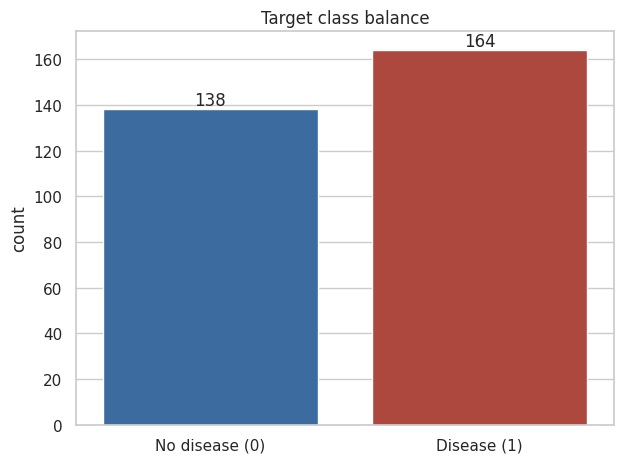

In [6]:
ax = sns.countplot(x=TARGET, data=cleaned, palette=["#2b6cb0", "#c0392b"])
ax.set_xticklabels(["No disease (0)", "Disease (1)"])
ax.set_title("Target class balance")
ax.set_xlabel("")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
counts = cleaned[TARGET].value_counts().to_dict()
print("Counts:", counts)
print("Positive rate: %.1f%%" % (100*counts[1]/sum(counts.values())))
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/class_balance.png", dpi=130); plt.show()

**Observation:** The classes are only mildly imbalanced (~54% positive), so plain
accuracy is *not* wildly misleading here — but we will still report precision, recall
and ROC-AUC, since in a clinical screening context recall (catching true cases) matters
more than raw accuracy.

## 4. Numeric feature distributions

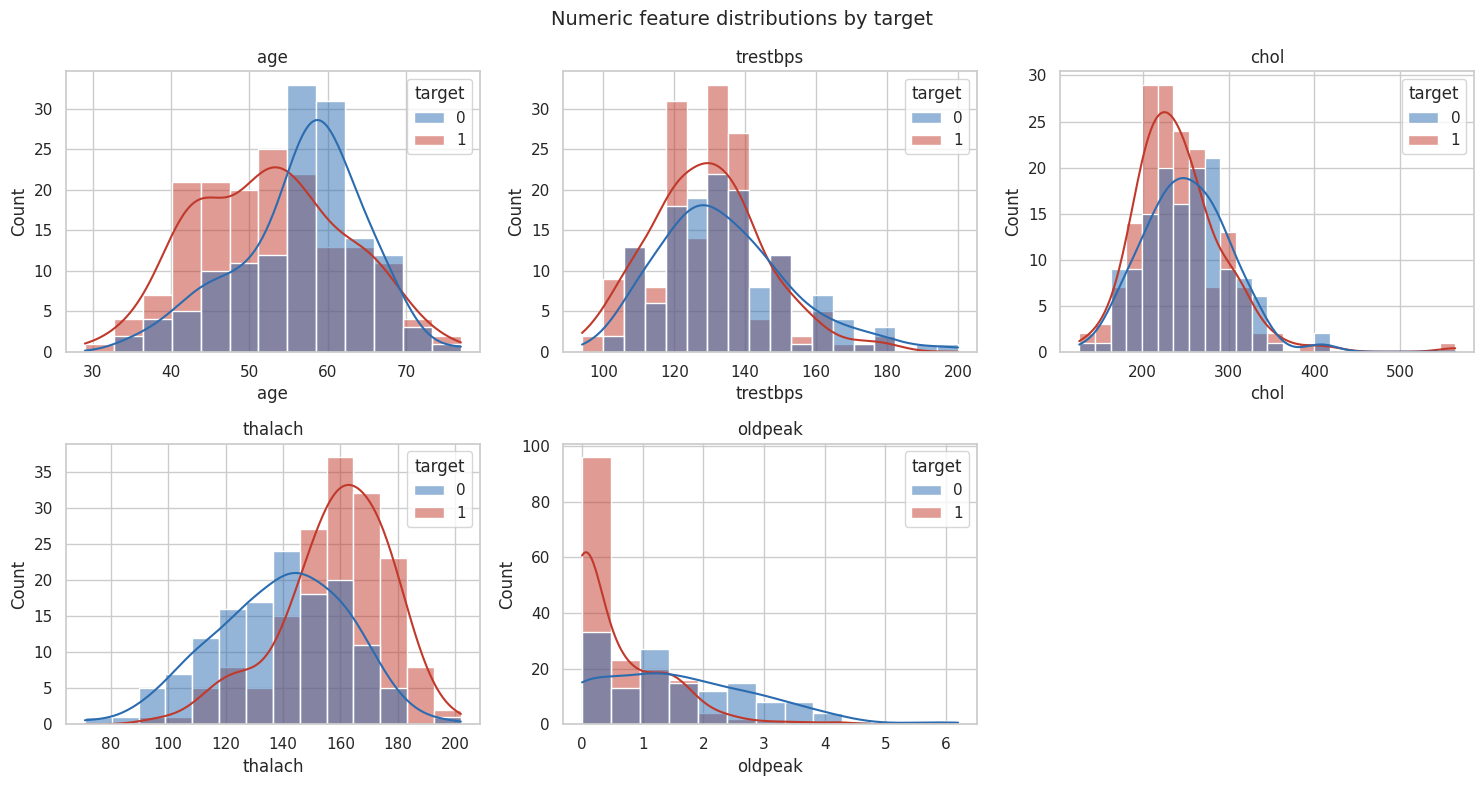

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    sns.histplot(data=cleaned, x=col, hue=TARGET, kde=True, ax=ax,
                 palette=["#2b6cb0", "#c0392b"], alpha=0.5)
    ax.set_title(col)
axes.flat[-1].axis("off")  # 5 features, 6 slots
fig.suptitle("Numeric feature distributions by target", fontsize=14)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/numeric_distributions.png", dpi=130); plt.show()

**Observation:** `thalach` (max heart rate) skews higher for the no-disease group,
while `oldpeak` (ST depression) and `age` skew higher for the disease group — all
clinically sensible and promising as predictive signals.

## 5. Correlation heatmap

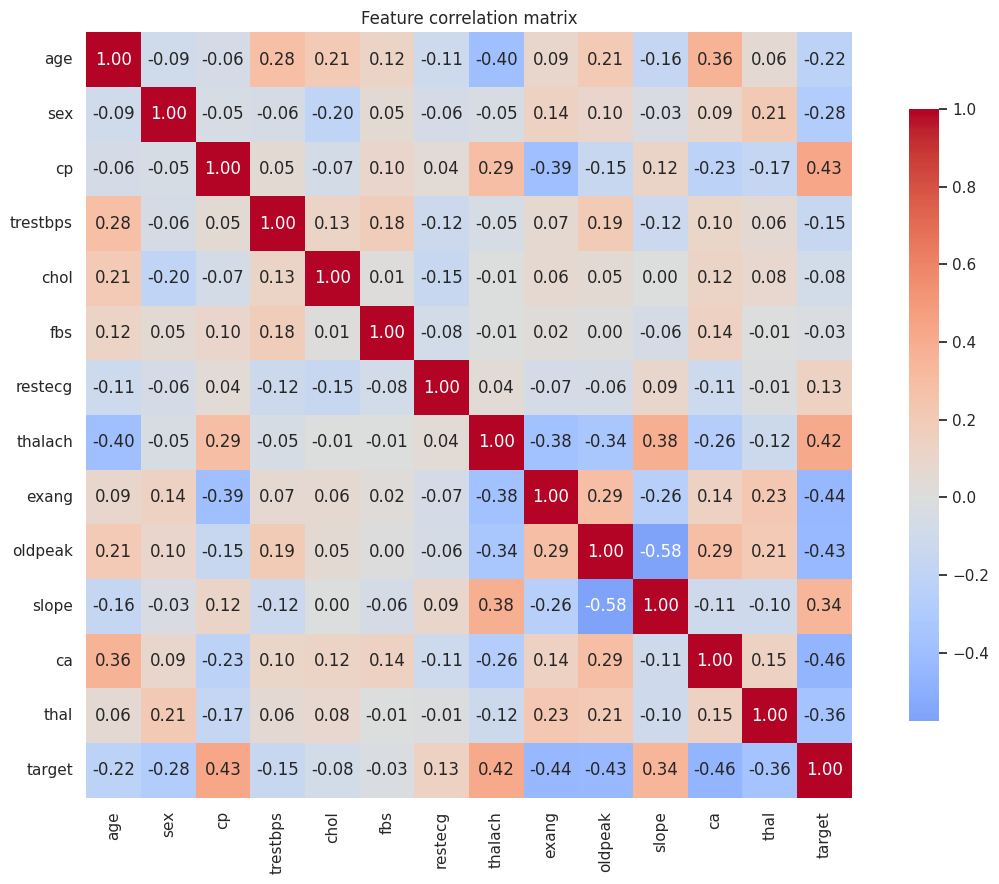

In [8]:
plt.figure(figsize=(12, 9))
corr = cleaned.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": .8})
plt.title("Feature correlation matrix")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/correlation_heatmap.png", dpi=130); plt.show()

In [9]:
# Features most correlated with the target
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Correlation with target (by |r|):")
print(target_corr)

Correlation with target (by |r|):
ca         -0.464357
exang      -0.435601
cp          0.432080
oldpeak    -0.429146
thalach     0.419955
thal       -0.364247
slope       0.343940
sex        -0.283609
age        -0.221476
trestbps   -0.146269
restecg     0.134874
chol       -0.081437
fbs        -0.026826
Name: target, dtype: float64


**Observation:** `cp` (chest-pain type), `thalach`, `exang`, `oldpeak`, and `ca`
show the strongest association with the target. No pair of predictors is dangerously
collinear, so we can keep all features.

## 6. Categorical / binary features vs target

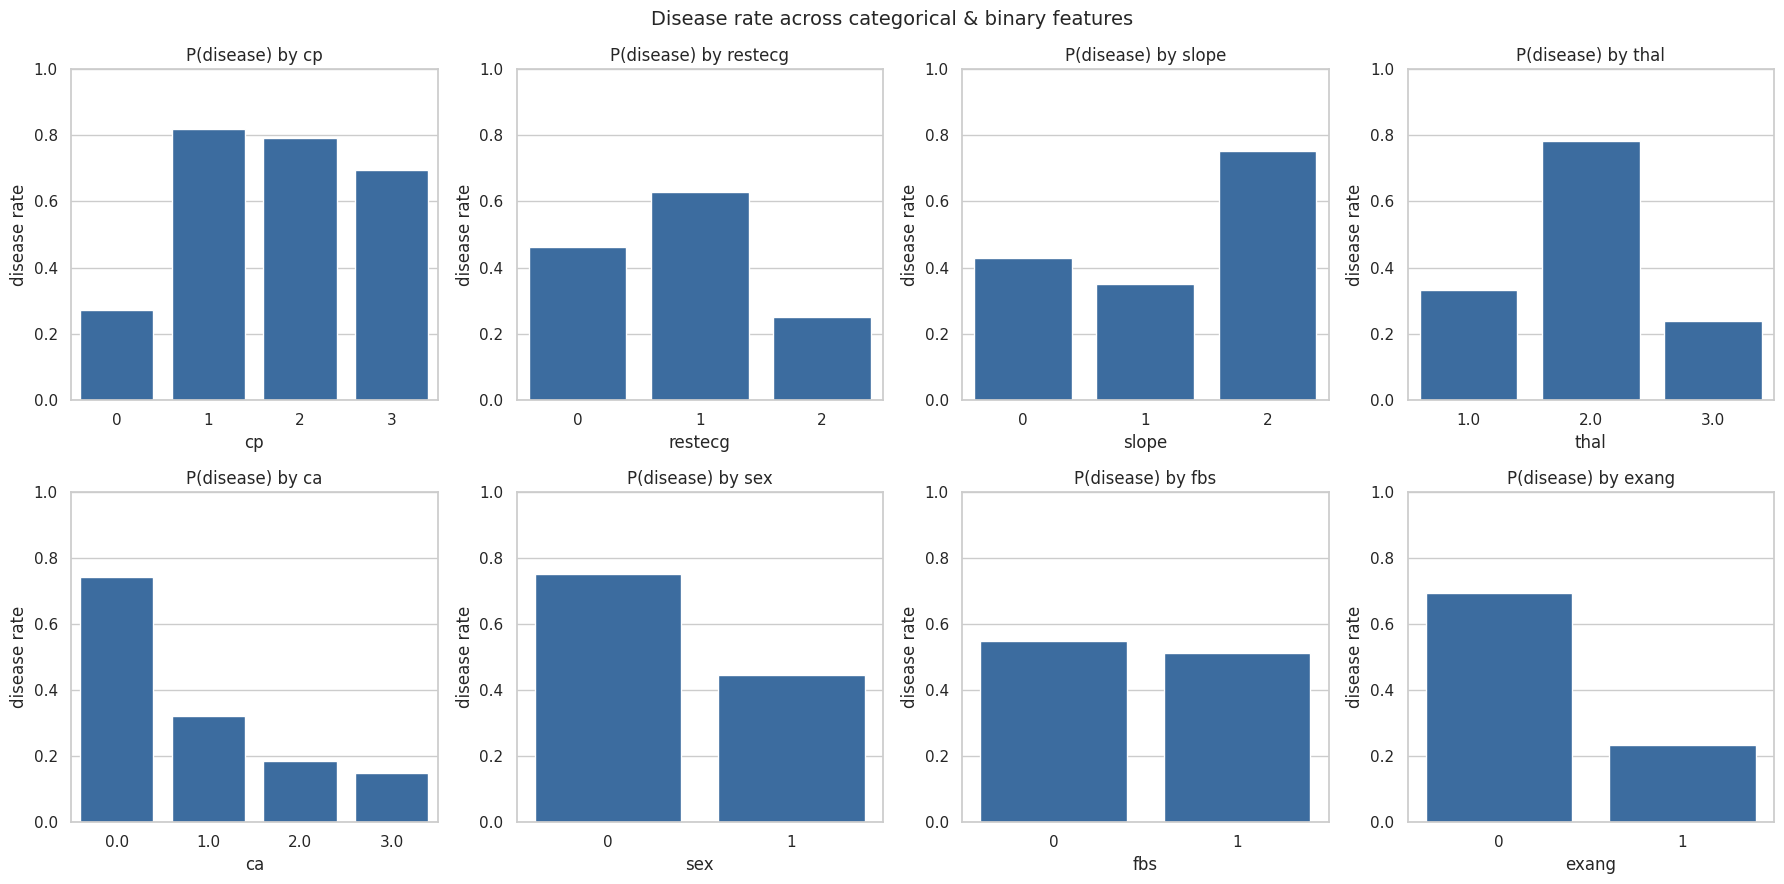

In [10]:
cat_bin = CATEGORICAL_FEATURES + BINARY_FEATURES
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.flat, cat_bin):
    prop = (cleaned.groupby(col)[TARGET].mean())
    sns.barplot(x=prop.index.astype(str), y=prop.values, ax=ax, color="#2b6cb0")
    ax.set_title(f"P(disease) by {col}")
    ax.set_ylabel("disease rate"); ax.set_ylim(0, 1)
for ax in axes.flat[len(cat_bin):]:
    ax.axis("off")
fig.suptitle("Disease rate across categorical & binary features", fontsize=14)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/categorical_vs_target.png", dpi=130); plt.show()

**Observation:** Disease rate varies sharply across `cp`, `ca`, `thal`, `slope`
and `exang`, confirming they carry signal and justifying one-hot encoding for the
multi-level categoricals.

## 7. EDA summary — choices this drives

- **Cleaning:** coerce `ca==4` / `thal==0` to NaN; drop duplicates. (1 duplicate found.)
- **Missing values:** median-impute numerics, mode-impute categoricals *inside* the pipeline.
- **Encoding:** one-hot for `cp, restecg, slope, thal, ca`; pass through binary `sex, fbs, exang`.
- **Scaling:** standard-scale numerics (helps Logistic Regression; harmless for trees).
- **Metrics:** report accuracy, precision, recall, ROC-AUC; prioritise **recall** for screening.
- **Validation:** stratified cross-validation to respect the mild class imbalance.

Next notebook: **feature engineering, model development, and MLflow tracking.**
